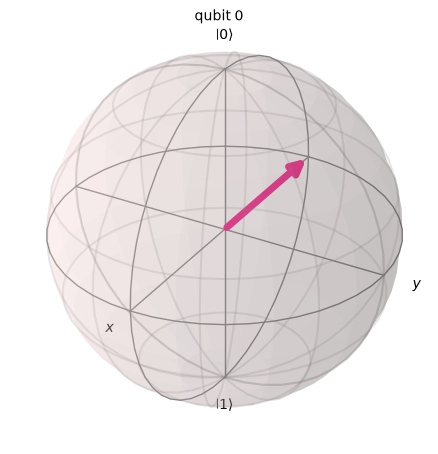

In [8]:
# Superposition quantique
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

# Circuit avec état |0⟩
qc = QuantumCircuit(1)

# Inverser l'état du qubit avec x (NOT)
qc.x(0)

# Appliquer H pour la superposition

qc.h(0)

# Visualiser sur la sphère de Bloch (à partir du vecteur d'état quantique)
state = Statevector(qc)
plot_bloch_multivector(state)

     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 
{'010': 119, '001': 147, '110': 118, '100': 132, '011': 127, '000': 121, '111': 108, '101': 128}


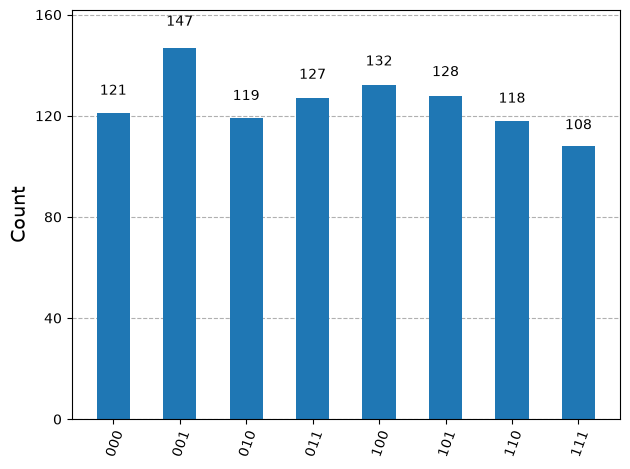

In [16]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Circuit avec 3 qubits
qc = QuantumCircuit(3, 3)

# Superposition sur les 3 qubits
qc.h(0)
qc.h(1)
qc.h(2)

# Mesurer tous les qubits
qc.measure([0, 1, 2], [0, 1, 2])

# Simuler
simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()
counts = result.get_counts()

# Visualiser
print(qc.draw())
print(counts)
plot_histogram(counts)

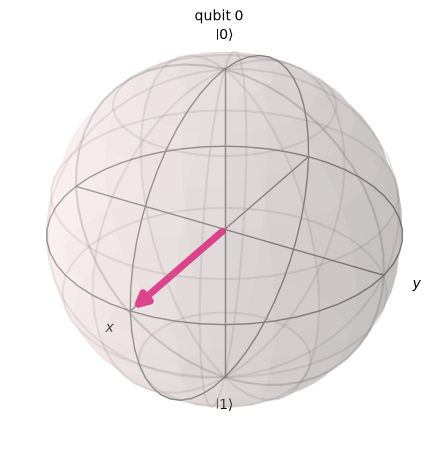

In [17]:
# Les états de Bell 
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# État |+⟩
qc_plus = QuantumCircuit(1)
qc_plus.h(0)
plot_bloch_multivector(Statevector(qc_plus))



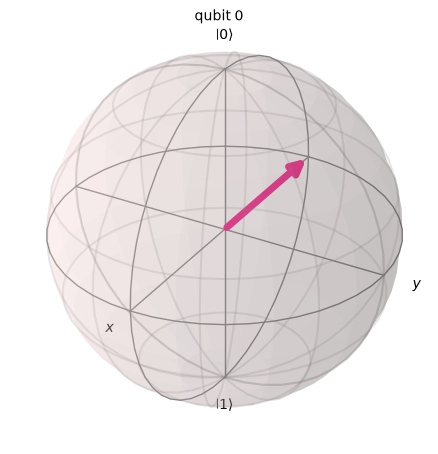

In [18]:
# État |-⟩
qc_minus = QuantumCircuit(1)
qc_minus.x(0)
qc_minus.h(0)
plot_bloch_multivector(Statevector(qc_minus))

Angle 0.00:
Angle 0.79:
Angle 1.57:
Angle 2.36:
Angle 3.14:
Angle 3.14:


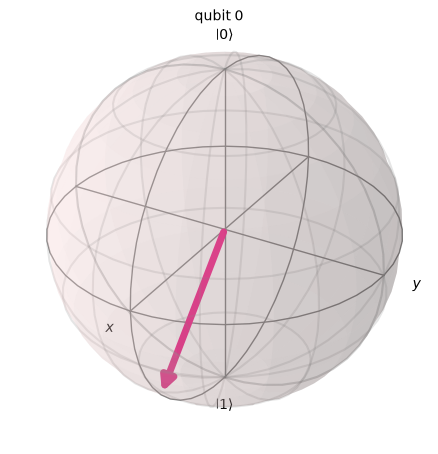

In [24]:
# Faire des rotations personnalisées dans la sphère de Bloch
import numpy as np

# Créer un état avec angle θ
def create_rotated_state(theta):
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    return qc

# Testez avec différents angles
for angle in [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]:
    qc = create_rotated_state(angle)
    print(f"Angle {angle:.2f}:")
qc = create_rotated_state(3*np.pi/4)
plot_bloch_multivector(Statevector(qc))

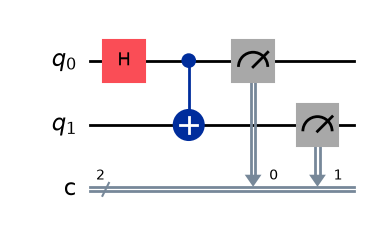

In [31]:
# Le circuit de l'intrication
from qiskit import QuantumCircuit

# Circuit avec 2 qubits et 2 bits
qc = QuantumCircuit(2, 2)

# Mettre le qubit de contrôle en superposition
qc.h(0)
# CNOT : contrôle=0, cible=1
qc.cx(0, 1)

# Mesurer
qc.measure([0, 1], [0, 1])

qc.draw(output='mpl')


Résultats :
{'00': 473, '11': 551}


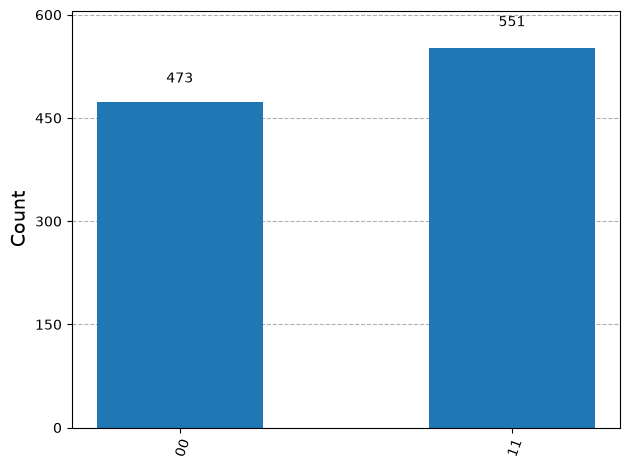

In [32]:
# Simuler
simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print("\nRésultats :")
print(counts)

plot_histogram(counts)